# Epsilon-Greedy Action Selection: Effect of ε

- This notebook compares the performance of ε-greedy agents on a stationary 10-armed bandit problem (Gaussian-distributed arms) with four different exploration rates: **ε = 0, 0.01, 0.1, 0.4**.

- We evaluate each agent on two metrics — average reward and % optimal action selected — to see how the exploration–exploitation trade-off controlled by ε affects both short-term and long-term performance.

In [ ]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt


module_path = Path.cwd().parent.resolve()

if str(module_path) not in sys.path:
    sys.path.append(str(module_path))


from bandit_engine import gaussian_arms_factory
from agents import EpsilonGreedyAgent
from run_experiments import compare_agents
from utils import plot_bandit_performance

In [ ]:
RANDOM_SEED = 42
epsilons = [0.0, 0.01, 0.1, 0.4]
k_arms = 10

agent_configs = [
    {
        "label": f"Epsilon-Greedy (eps={eps})",
        "agent_type": EpsilonGreedyAgent,
        "agent_config": {
            "n_arms": k_arms,
            "epsilon": eps,
            "initial_value": 0.0
        }
    }
    for eps in epsilons
]

# Set experiment parameters and run comparison
n_runs = 2000
n_steps = 1000
non_stationary = False

results = compare_agents(
    arm_factory=gaussian_arms_factory,
    agent_configs=agent_configs,
    random_seed=RANDOM_SEED,
    n_runs=n_runs,
    n_steps=n_steps,
    non_stationary=non_stationary
)

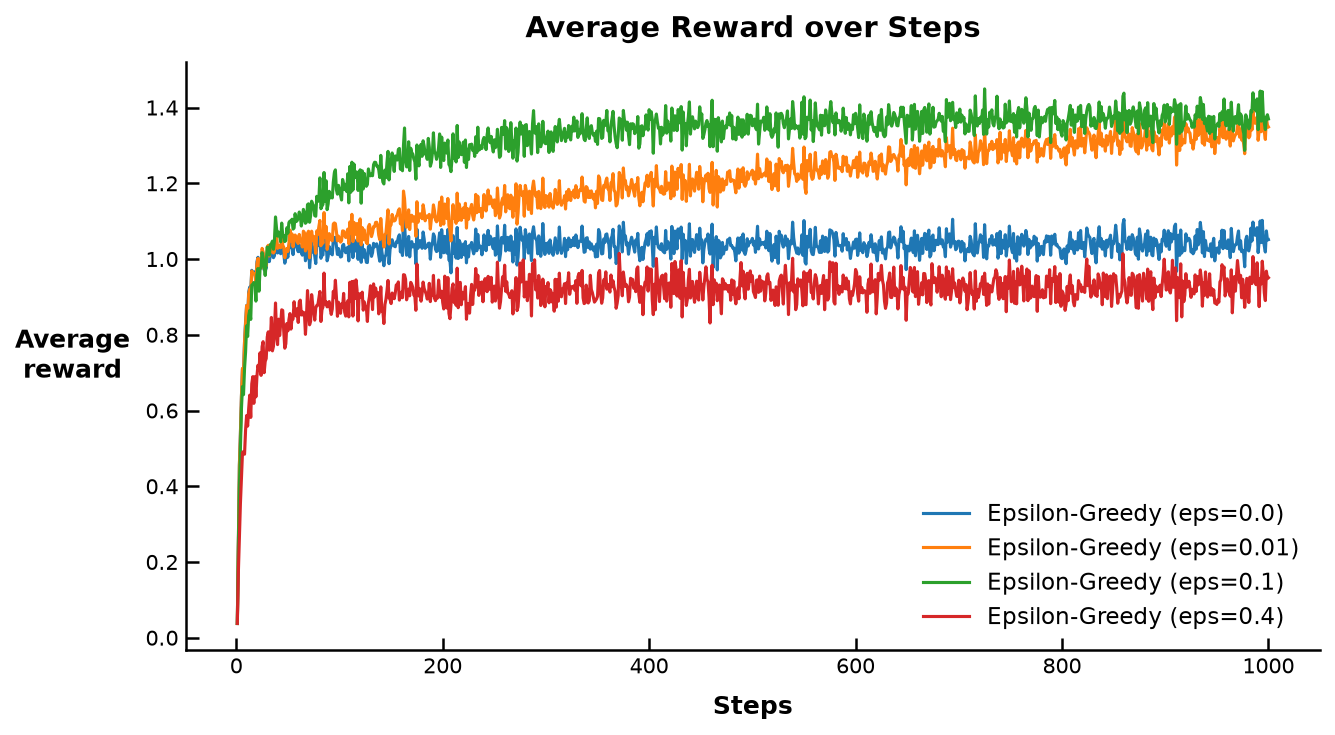

In [ ]:
# Run and plot experiment with different epsilon value, including: 0 (greedy), 0.01, 0.1, and 0.4

# Unpack the results tuple into separate dictionaries for each metric
rewards_dict = {label: data[0] for label, data in results.items()}
optimal_actions_dict = {label: data[1] for label, data in results.items()}

# Custom color mapping matching the agent labels used in agent_configs
custom_colors = {
    "Epsilon-Greedy (eps=0.0)": "#1F77B4",
    "Epsilon-Greedy (eps=0.01)": "#FF7F0E",
    "Epsilon-Greedy (eps=0.1)": "#2CA02C",
    "Epsilon-Greedy (eps=0.4)": "#D62728"
}

fig_reward, ax_reward = plot_bandit_performance(
    metrics_data=rewards_dict,
    metric_type="reward",
    title="Average Reward over Steps",
    colors=custom_colors
)

plt.show()

## Observations:
- The agent with ε = 0.4 performs worst overall. Because it explores so frequently, it wastes a large fraction of its steps on non-optimal actions even after it has gathered enough information to know better, which caps its long-run average reward.
- The fully greedy agent (ε = 0.0) plateaus early around an average reward of ~1.0. Since it never explores beyond its initial estimates, it quickly locks onto whichever action looks best after only a few pulls — which is not necessarily the true optimal action — and has no mechanism to discover a better one afterward.
- Between the two remaining agents, ε = 0.1 dominates early on thanks to a good exploration–exploitation balance: it explores enough to find high-value actions quickly while still exploiting them often. The ε = 0.01 agent explores much more slowly, so it takes longer to discover the optimal action, but by around step 700–800 it catches up and reaches a similar average reward to ε = 0.1, since by then it has gathered enough information and settles into exploiting effectively.

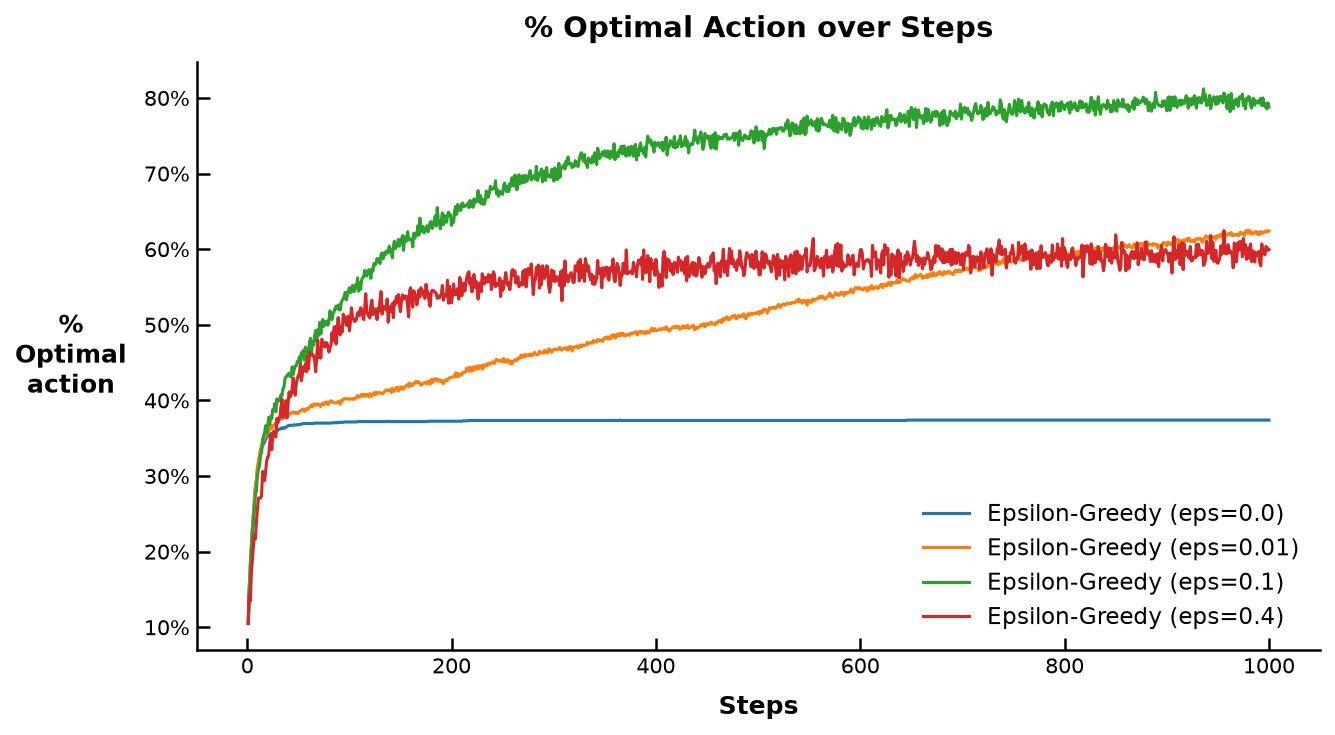

In [5]:
fig_optimal, ax_optimal = plot_bandit_performance(
    metrics_data=optimal_actions_dict,
    metric_type="optimal_action",
    title="% Optimal Action over Steps",
    colors=custom_colors
)
plt.show()

## Observations:

- The ε = 0.0 (fully greedy) agent has the lowest optimal-action rate, flattening out early at a low percentage. Because it never explores past its initial value estimates, it commits early to whatever action happens to look best from a small, noisy sample — and since it stops updating its belief about other actions, this early choice is frequently *not* the true optimal action.
- The ε = 0.4 agent explores much more aggressively, which helps it identify the true optimal action more reliably than the greedy agent, giving it a higher optimal-action rate early on.
- The ε = 0.01 agent starts slow, since its low exploration rate means it takes longer to sample enough actions to identify the optimal one. However, given enough steps, its accumulated knowledge lets it consistently exploit the correct action, and it eventually overtakes ε = 0.4 in optimal-action percentage in the later steps.
- The ε = 0.1 agent achieves the best balance overall — enough exploration to reliably discover the optimal action, and enough exploitation to consistently select it — resulting in the highest % optimal action by the end of the run.